# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

In [2]:
df_chem = pd.read_csv("chembl_200-500_10k.csv")
df_anti = pd.read_csv("pubchem_antibiotics.csv")

In [3]:
df_chem.head(5)

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,SMILES,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."


In [4]:
df_anti.head(5)

,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


In [5]:
df_chem.describe()

,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,HBA,HBD,#RO5 Violations,#Rotatable Bonds,QED Weighted,Aromatic Rings,Inorganic Flag,Heavy Atoms,Np Likeness Score,Orphan
count,75.000000,10000.000000,9593.000000,9593.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,10000.000000,9946.000000,9946.000000,10000.000000
mean,2.026667,367.632781,6.980298,10.977692,3.293754,72.823139,4.775990,1.357631,0.134627,4.922180,0.613163,2.359240,-0.992500,25.737181,-0.921939,-0.992400
std,1.314918,71.308667,14.499846,72.107042,1.570448,30.772358,1.843906,1.153433,0.343983,2.604628,0.182504,1.091465,0.086281,5.227196,1.015270,0.087994
min,-1.000000,200.280000,1.000000,1.000000,-5.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,-1.000000,8.000000,-4.070000,-1.000000
25%,2.000000,315.502500,1.000000,2.000000,2.340000,51.100000,3.000000,1.000000,0.000000,3.000000,0.480000,2.000000,-1.000000,22.000000,-1.590000,-1.000000
50%,2.000000,368.455000,3.000000,5.000000,3.335000,69.910000,5.000000,1.000000,0.000000,5.000000,0.620000,2.000000,-1.000000,26.000000,-1.080000,-1.000000
75%,3.000000,423.525000,7.000000,10.000000,4.290000,91.287500,6.000000,2.000000,0.000000,6.000000,0.760000,3.000000,-1.000000,30.000000,-0.460000,-1.000000
max,4.000000,499.700000,613.000000,5992.000000,9.930000,258.840000,16.000000,8.000000,2.000000,23.000000,0.950000,6.000000,0.000000,38.000000,4.110000,1.000000


In [6]:
df_anti.describe()

,Compound_CID,Molecular_Weight,Polar_Area,Complexity,XLogP,Heavy_Atom_Count,H-Bond_Donor_Count,H-Bond_Acceptor_Count,Rotatable_Bond_Count,Exact_Mass,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
count,2.358000e+03,2358.000000,2358.000000,2358.000000,1905.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,...,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2.358000e+03
mean,3.287431e+07,661.647590,227.031293,1169.944444,0.961995,45.955047,6.104750,12.417303,8.997880,661.124215,...,5.918999,2.529686,0.814673,0.715437,0.099237,1329.260814,5149.486429,1420.523325,6.229856,2.008519e+07
std,4.844780e+07,396.047313,164.974911,831.344101,3.740470,27.725970,5.913143,7.577051,8.422624,395.802160,...,6.683319,5.229701,1.589103,1.487333,0.602913,6876.501858,15182.253531,4224.227155,4.539714,5.056542e+04
min,3.200000e+02,99.090000,3.200000,38.000000,-16.700000,7.000000,0.000000,1.000000,0.000000,99.032028,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.004092e+07
25%,1.962080e+05,405.300000,128.000000,647.000000,-1.100000,28.000000,2.000000,7.000000,4.000000,404.219879,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,2.005081e+07
50%,6.450115e+06,544.550000,193.000000,944.000000,1.300000,38.000000,4.000000,11.000000,7.000000,543.775238,...,3.500000,0.000000,0.000000,0.000000,0.000000,6.000000,48.000000,18.000000,5.000000,2.006043e+07
75%,5.468076e+07,814.000000,261.000000,1460.000000,3.400000,58.000000,7.000000,15.000000,11.000000,813.451050,...,9.000000,2.000000,1.000000,1.000000,0.000000,126.750000,1592.000000,482.250000,9.000000,2.011123e+07
max,1.778574e+08,3545.100000,1690.000000,8160.000000,18.600000,243.000000,58.000000,63.000000,67.000000,3543.581543,...,37.000000,33.000000,14.000000,14.000000,10.000000,132224.000000,142293.000000,40785.000000,20.000000,2.026013e+07


Data cleaning

In [7]:
#name normalisation

df_chem = df_chem.rename(columns={
    "Molecular Weight" : "Molecular_Weight",
    "Polar Surface Area": "Polar_Area",
    "Heavy Atoms": "Heavy_Atom_Count",
    "#Rotatable Bonds": "Rotatable_Bond_Count",
    "SMILES":"Smiles"
    })
df_chem.head(1)

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular_Weight,Targets,Bioactivities,AlogP,Polar_Area,...,Heavy_Atom_Count,Np Likeness Score,Molecular Formula,Smiles,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...


Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [8]:
def normalise_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        pass
    return None

In [9]:
df_chem["norm_smiles"] = df_chem["Smiles"].apply(normalise_smiles)
df_anti["norm_smiles"] = df_anti["Smiles"].apply(normalise_smiles)
df_chem = df_chem.dropna(subset=["norm_smiles"])
df_anti = df_anti.dropna(subset=["norm_smiles"])



[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors
[21:14:53] WARNING: not removing hydrogen atom without neighbors


In [10]:
df_chem["mol"] = df_chem["norm_smiles"].apply(Chem.MolFromSmiles)
df_anti["mol"] = df_anti["norm_smiles"].apply(Chem.MolFromSmiles)

df_chem.head(2)

[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors
[21:14:56] WARNING: not removing hydrogen atom without neighbors


,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular_Weight,Targets,Bioactivities,AlogP,Polar_Area,...,Molecular Formula,Smiles,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name,norm_smiles,mol
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,<rdkit.Chem.rdchem.Mol object at 0x000001904A2...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']",COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,<rdkit.Chem.rdchem.Mol object at 0x00000190499...


In [11]:
#fingerprints


def morg_list(mol_col):
    morgan = GetMorganGenerator(radius=2,fpSize=2048) #as described in exercise

    listy = []
    for i in mol_col:
        listy.append(morgan.GetFingerprint(i))
    print(len(listy))
    return listy

df_chem_fp = list(morg_list(df_chem["mol"]))
df_anti_fp = list(morg_list(df_anti["mol"]))

9993
2358


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

### Chem

In [12]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
dists = []
fp_list_chem = df_chem_fp
nfps_chem = len(fp_list_chem)

for i in range(1, nfps_chem):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_chem[i], fp_list_chem[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_chem = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps_chem, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters_chem))

Number of clusters: 6824


### Antibiotics

In [13]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
dists = []
fp_list_anti = df_anti_fp
nfps_anti = len(fp_list_anti)

for i in range(1, nfps_anti):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_anti[i], fp_list_anti[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_anti = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps_anti, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters_anti))

Number of clusters: 542


### Chem

In [17]:
# filter out small clusters
clusters_filtered_chem = [c for c in butina_clusters_chem if len(c) >= 10]

butina_labels_chem = np.full(nfps_chem, -1)

for cluster_id, cluster in enumerate(clusters_filtered_chem):
    for id in cluster:
        butina_labels_chem[id] = cluster_id

# compute cluster sizes
sizes = [len(c) for c in clusters_filtered_chem]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 31
mean size: 14.483870967741936
max size: 30
singletons: 0


### Antibiotics

In [18]:
# filter out small clusters, rare chemotypes
clusters_filtered_anti = [c for c in butina_clusters_anti if len(c) >= 10]

butina_labels_anti = np.full(nfps_anti, -1)

for cluster_id, cluster in enumerate(clusters_filtered_anti):
    for id in cluster:
        butina_labels_anti[id] = cluster_id

# compute cluster sizes
sizes = [len(c) for c in clusters_filtered_anti]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 49
mean size: 28.06122448979592
max size: 125
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

### Chem

In [20]:
# use HDBSCAN for clustering
hdbs_clustering_chem = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels_chem = hdbs_clustering_chem.fit_predict(fp_list_chem)
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_chem)) - (1 if -1 in hdbs_labels_chem else 0))
print("Noise points:", list(hdbs_labels_chem).count(-1))

Number of DBSCAN clusters: 4
Noise points: 5395


### Antibiotics

In [21]:
# use HDBSCAN for clustering
hdbs_clustering_anti = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels_anti = hdbs_clustering_anti.fit_predict(fp_list_anti)
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_anti)) - (1 if -1 in hdbs_labels_anti else 0))
print("Noise points:", list(hdbs_labels_anti).count(-1))

Number of DBSCAN clusters: 55
Noise points: 1046


### Chem

In [22]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_chem)) - (1 if -1 in hdbs_labels_chem else 0))
print("Noise points:", list(hdbs_labels_chem).count(-1))

Number of DBSCAN clusters: 4
Noise points: 5395


### Antibiotics

In [23]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_anti)) - (1 if -1 in hdbs_labels_anti else 0))
print("Noise points:", list(hdbs_labels_anti).count(-1))

Number of DBSCAN clusters: 55
Noise points: 1046


Embeddings: TSNE and UMAP

### Chem

In [24]:
# convert fingerprints to numpy
X_chem = np.zeros((nfps_chem, 2048), dtype=int)
for i, fp in enumerate(fp_list_chem):
    DataStructs.ConvertToNumpyArray(fp, X_chem[i])

### Antibiotics

In [25]:
# convert fingerprints to numpy
X_anti = np.zeros((nfps_anti, 2048), dtype=int)
for i, fp in enumerate(fp_list_anti):
    DataStructs.ConvertToNumpyArray(fp, X_anti[i])

### Chem

In [26]:
# Dimensionality reduction by TSNE
umap_chem = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding_chem = umap_chem.fit_transform(X_chem)

c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Antibiotics

In [27]:
# Dimensionality reduction by TSNE
umap_anti = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding_anti = umap_anti.fit_transform(X_anti)

c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Chem

In [31]:
# Dimensionality reduction by TSNE
tsne_model_chem = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding_chem = tsne_model_chem.fit_transform(X_chem)

### Antibiotics

In [32]:
# Dimensionality reduction by TSNE
tsne_model_anti = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding_anti = tsne_model_anti.fit_transform(X_anti)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

### Chem

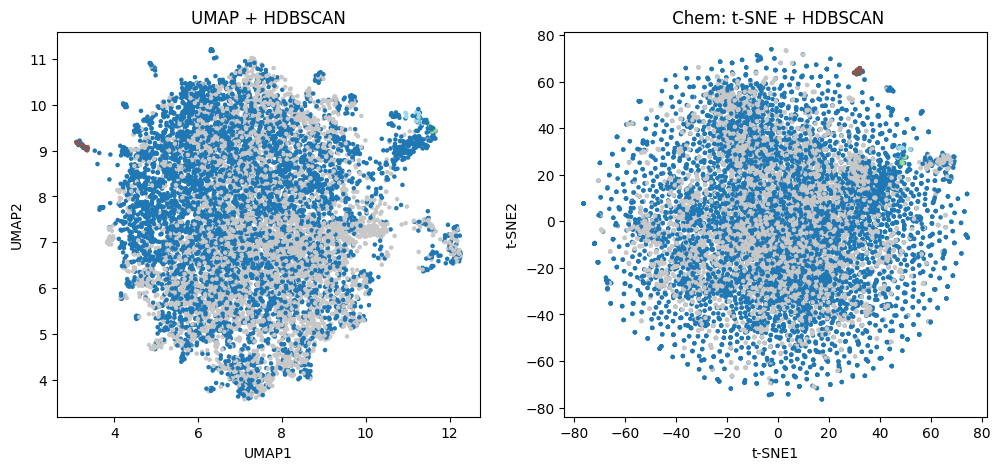

In [33]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(
    umap_embedding_chem[:,0],
    umap_embedding_chem[:,1],
    c=hdbs_labels_chem,
    cmap="tab20",
    s=5
)
axes[0].set_title("UMAP + HDBSCAN")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

axes[1].scatter(
    tsne_embedding_chem[:,0],
    tsne_embedding_chem[:,1],
    c=hdbs_labels_chem,
    cmap="tab20",
    s=5
)
axes[1].set_title(" Chem: t-SNE + HDBSCAN")
axes[1].set_xlabel("t-SNE1")
axes[1].set_ylabel("t-SNE2")

plt.show()

### Antibiotics

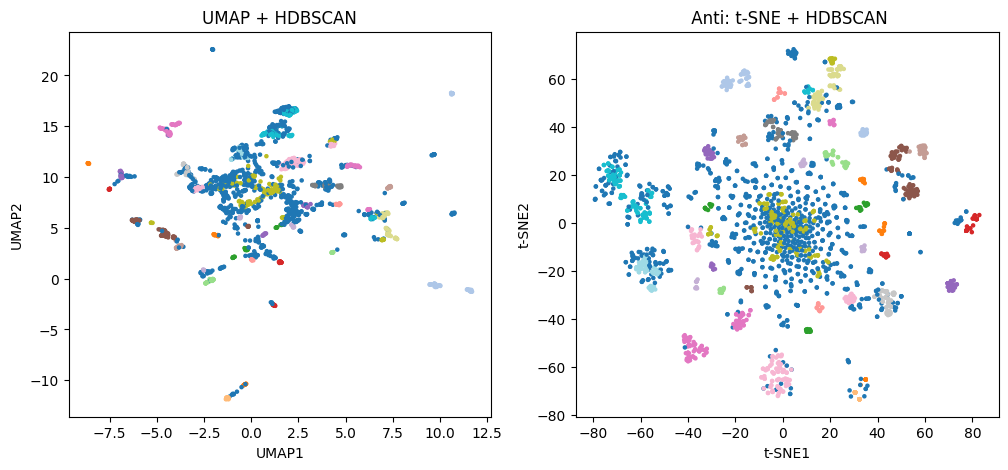

In [34]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(
    umap_embedding_anti[:,0],
    umap_embedding_anti[:,1],
    c=hdbs_labels_anti,
    cmap="tab20",
    s=5
)
axes[0].set_title("UMAP + HDBSCAN")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

axes[1].scatter(
    tsne_embedding_anti[:,0],
    tsne_embedding_anti[:,1],
    c=hdbs_labels_anti,
    cmap="tab20",
    s=5
)
axes[1].set_title(" Anti: t-SNE + HDBSCAN")
axes[1].set_xlabel("t-SNE1")
axes[1].set_ylabel("t-SNE2")

plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

### Chem

In [35]:
from collections import Counter

cluster_counts_chem = Counter(hdbs_labels_chem)
cluster_counts_chem.pop(-1, None)

largest_clusters_chem = [c for c,_ in cluster_counts_chem.most_common(3)]

print(largest_clusters_chem)

[np.int64(2), np.int64(1), np.int64(3)]


### Antibiotics

In [36]:
from collections import Counter

cluster_counts_anti = Counter(hdbs_labels_anti)
cluster_counts_anti.pop(-1, None)

largest_clusters_anti = [c for c,_ in cluster_counts_anti.most_common(3)]

print(largest_clusters_anti)

[np.int64(44), np.int64(35), np.int64(32)]


### Chem

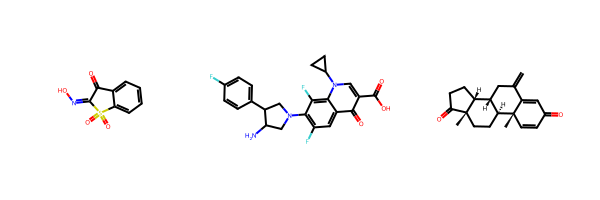

In [37]:
reps_chem = []

for c in largest_clusters_chem:
    idx = np.where(hdbs_labels_chem == c)[0][0]
    reps_chem.append(df_chem.iloc[idx]["mol"])

Draw.MolsToGridImage(reps_chem, molsPerRow=3)

### Antibiotics

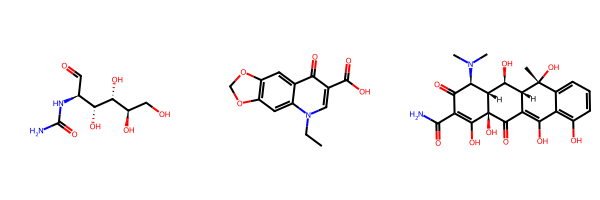

In [38]:
reps_anti = []

for c in largest_clusters_anti:
    idx = np.where(hdbs_labels_anti == c)[0][0]
    reps_anti.append(df_anti.iloc[idx]["mol"])

Draw.MolsToGridImage(reps_anti, molsPerRow=3)

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


#### Discussion of Results

1. The small molecule dataset is very broad and has very different chemical subsets whereas the antibiotic one is a lot more narrow. This is because it is compromised of a very distinct group of functional compounds with a clear goal. This leads to very different chemical distributions
2.  Density-based methods group molecules are based on spatial proximity in the feature space and are highly dependent on parameters such as the density threshold and cluster size. Similarity-based approaches such as Butina clustering group molecules based on fingerprint similarity rather than spatial density and do not require specifying the number of clusters in advance.
3. Butina lead to 31 clusters for the small molecule dataset and 49 for antibiotics respectively and DBSCAN lead to 4 clusters for small molecules and 55 for antibiotics. This suggests that antibiotics form a more closely knit structure because of more similarity
4. t-SNE only preserves local neighbourhoods but does not care about global relationships which leads to information loss and possible mis-interpretation if distances are "measured". UMAP preserves both local and global structures.
5.I would say that a combination of DBSCAN + UMAP would work best as structure is preserved from UMAP and dense clusters are found using DBSCAN which makes more sense for this structural analysis. 
6.Some key takeaways were the long run-time of the DBSCAN algorithm on the small molecule dataset so if the trade-off is not too big and time is a concern e.g. if done on the whole dataset then it might be good to choose a different combination. It might also be good to do hyperparameter tuning (such as grid search) to find one that reduces noise.
7. One of the structures looks very similar to tetracycline or doxycycline and two of the 3 main groups extracted from the draw tool have large conjugated pi systems.
